# Insurance Fraud Detection

**Project Overview**

Insurance fraud is one of the most persistent and costly problems in the financial services industry, draining billions in claim payouts every year. In this project, I am building a machine learning pipeline to flag fraudulent insurance claims from a dataset of 51,000 records. The data covers a wide range of signals including customer demographics, policy financials, claim history, incident details, and behavioral risk scores. The target variable is a binary fraud label, making this a supervised classification technique. My goal is not just maximum accuracy but a model that catches as many fraud cases as possible with an acceptable false positive rate.

\Importing necessary libraries

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re



import warnings
warnings.filterwarnings("ignore")

pd.set_option('display.max_columns', None)


\Loading the dataset

In [36]:
df= pd.read_csv(r"C:\NG\insurance_fraud_detection\data\raw\insurance_claim_fraud_detection_dataset(in).csv")


\data inspection

In [37]:
df.head()

,claim_id,customer_age,gender,occupation,location_type,customer_tenure_years,policy_type,policy_duration_years,premium_amount,annual_premium,coverage_amount,policy_value,deductible_amount,policy_changes_last_year,claim_amount,repair_estimate,claim_type,incident_severity,incident_location,previous_claims_count,claims_last_12_months,total_claim_amount_previous,claim_frequency_score,police_report_available,witness_available,third_party_involved,incident_hour,weekend_incident,documentation_score,suspicious_activity_score,claim_amount_to_coverage_ratio,premium_to_claim_ratio,policy_start_date,policy_end_date,incident_date,claim_filed_date,claim_settlement_date,claim_submission_delay_days,fraud_investigation_result,claim_rejected,legal_case_filed,settlement_approved,fraud
0,CLM000001,49,Female,Self-employed,Semi-Urban,7.4,Property,3.3,"$22,420",21067,"$486,870",479675,"$11,790",4,"$20,218","$41,020",Medical,Major,Public Place,0.0,1,0,1.83,Yes,Yes,Yes,11,Yes,10.00,4.90,4.15%,110.89%,8/3/2020,2/4/2024,24-May-23,31/05/2023,7/22/2023,7.0,Clear,No,No,Yes,0
1,CLM000002,29,Female,Business,Urban,5.5,auto,3.8,"$15,431",17382,"$721,974",739819,"$12,548",1,"$222,106","$241,421",Medical,Major,Road,1.0,0,62030,2.31,Yes,Yes,No,2,Yes,7.66,5.74,30.76%,6.95%,9/1/2022,1/25/2025,8/13/2024,19-Aug-24,12/19/2024,6.0,Clear,No,No,Yes,0
2,CLM000003,35,male,Salaried,Semi-Urban,1.5,AUTO,7.7,"$18,243",18357,"$892,064",917373,"$24,292",0,"$5,000","$8,655",Accident,Minor,Road,1.0,2,7985,5.20,No,No,No,19,Yes,7.43,2.01,0.56%,364.86%,29-Mar-23,29-11-2024,4-Sep-22,23-Sep-22,10/25/2022,19.0,Clear,No,No,Yes,0
3,CLM000004,24,Female,Business,Urban,7.2,Auto,5.7,"$18,491",18006,"$50,000",156216,"$1,000",3,"$212,674","$239,787",Medical,Minor,Hospital,2.0,1,227104,5.62,no,Yes,No,22,Yes,9.77,5.40,425.35%,8.69%,18/07/2018,8/20/2019,31-12-2022,3/11/2023,5/24/2023,70.0,Clear,No,No,Yes,0
4,CLM000005,41,Male,Salaried,Urban,5.4,Travel,5.3,"$17,354",16708,"$50,000",50271,"$2,717",0,"$73,521","$103,984",Theft,Moderate,Hospital,1.0,0,63514,0.60,No,Yes,Yes,8,No,7.00,6.76,147.04%,23.60%,25-Aug-23,3/24/2027,5/9/2024,11/6/2024,13-12-2024,62.0,Clear,No,No,Yes,0


#### Observations from Initial Data Inspection

- Monetary columns (`premium_amount`, `coverage_amount`, `claim_amount`, `deductible_amount`) are stored as strings with `$` signs and commas — I need to strip and convert these to numeric before any analysis.
- Date columns (`policy_start_date`, `incident_date`, `claim_filed_date`) use inconsistent formats across rows, which will need careful parsing.
- `policy_type` has mixed casing (`auto`, `AUTO`, `Auto`) and `police_report_available` has mixed cases (`Yes`/`no`) — case normalization is necessary across several columns.
- The dataset captures rich behavioral signals like `suspicious_activity_score`, `claim_frequency_score`, and `documentation_score` — these engineered features will likely be strong model inputs.
- `claim_id` is a unique row identifier and will not be useful as a model feature — I will drop it during preprocessing.

In [38]:
df.shape

(51000, 43)

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51000 entries, 0 to 50999
Data columns (total 43 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   claim_id                        51000 non-null  object 
 1   customer_age                    51000 non-null  int64  
 2   gender                          51000 non-null  object 
 3   occupation                      51000 non-null  object 
 4   location_type                   51000 non-null  object 
 5   customer_tenure_years           48448 non-null  float64
 6   policy_type                     51000 non-null  object 
 7   policy_duration_years           51000 non-null  float64
 8   premium_amount                  51000 non-null  object 
 9   annual_premium                  51000 non-null  int64  
 10  coverage_amount                 51000 non-null  object 
 11  policy_value                    51000 non-null  int64  
 12  deductible_amount               

In [40]:
df.describe()

,customer_age,customer_tenure_years,policy_duration_years,annual_premium,policy_value,policy_changes_last_year,previous_claims_count,claims_last_12_months,total_claim_amount_previous,claim_frequency_score,incident_hour,documentation_score,suspicious_activity_score,claim_submission_delay_days,fraud
count,51000.000000,48448.000000,51000.000000,51000.000000,5.100000e+04,51000.000000,51000.000000,51000.000000,5.100000e+04,51000.000000,51000.000000,48451.000000,51000.000000,51000.000000,51000.000000
mean,46.334588,5.063342,4.098227,19251.113490,7.417385e+05,0.693255,2.162859,0.743020,1.008335e+05,3.422625,11.469549,6.946812,3.573832,51.303934,0.079961
std,16.912850,2.870695,2.336776,9998.118672,4.624669e+05,1.042775,9.039540,1.011067,1.478807e+05,2.941291,6.963658,1.889449,2.318556,66.772974,0.271235
min,-10.000000,0.000000,0.000000,-8343.000000,-1.502950e+05,0.000000,0.000000,0.000000,-3.657850e+05,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,32.000000,3.000000,2.300000,11980.750000,3.774558e+05,0.000000,0.000000,0.000000,0.000000e+00,0.870000,5.000000,5.660000,1.790000,23.000000,0.000000
50%,46.000000,5.000000,4.000000,19001.500000,7.186285e+05,0.000000,1.000000,0.000000,4.095900e+04,2.800000,11.000000,7.010000,3.490000,46.000000,0.000000
75%,61.000000,7.000000,5.700000,26073.250000,1.058897e+06,1.000000,2.000000,1.000000,1.470055e+05,5.370000,17.000000,8.360000,5.170000,69.000000,0.000000
max,75.000000,17.000000,14.700000,61805.000000,2.791303e+06,4.000000,90.762375,4.000000,1.141862e+06,10.000000,30.000000,10.000000,10.000000,664.947871,1.000000


#### Key Statistical Observations

- `customer_age` has a minimum of **-10**, which is clearly invalid — negative ages are data entry errors that need to be corrected or filtered out.
- `annual_premium` goes as low as **-8343** and `policy_value` also has negatives — financial values cannot be negative and these are data quality issues to address.
- `previous_claims_count` maxes at **90.76**, suspiciously high and likely an outlier — I will investigate and cap this during cleaning.
- `incident_hour` has a maximum of **30**, which is outside the valid 0-23 hour range and needs correction before feature engineering.
- `claim_submission_delay_days` averages ~51 days with a max of **664** — extreme delays could themselves be a useful fraud signal worth retaining as a feature.

\Missing value analysis

In [41]:
(df.isnull().sum()/len(df)*100).sort_values(ascending=False)

incident_severity                 5.005882
customer_tenure_years             5.003922
police_report_available           5.000000
documentation_score               4.998039
witness_available                 4.998039
repair_estimate                   4.919608
claim_amount                      4.909804
gender                            0.000000
occupation                        0.000000
customer_age                      0.000000
claim_id                          0.000000
coverage_amount                   0.000000
annual_premium                    0.000000
premium_amount                    0.000000
policy_duration_years             0.000000
policy_type                       0.000000
location_type                     0.000000
policy_changes_last_year          0.000000
deductible_amount                 0.000000
incident_location                 0.000000
claim_type                        0.000000
previous_claims_count             0.000000
claims_last_12_months             0.000000
claim_frequ

#### Missing Value Observations

- 7 columns have missing values, all hovering around **~5%** — the uniform rate suggests a structured dropout pattern rather than purely random missingness.
- `claim_amount` and `repair_estimate` are missing ~4.9% — these are directly fraud-relevant fields, so I will use targeted imputation rather than dropping those rows.
- Missing values in `documentation_score` and `witness_available` may not be random — in fraud cases, the absence of supporting documents is often deliberate.
- `incident_severity` missingness (~5%) matters because severity strongly drives claim amounts, so imputing it poorly could introduce noise into the model.
- The remaining 36 columns are fully complete, which gives a solid base to build from.

\Duplicate values check

In [42]:
df.duplicated().sum()

np.int64(1000)

#### Duplicate Records

- Found **1,000 exact duplicate rows**, accounting for ~2% of the dataset — these will be dropped before any analysis or modeling.
- In fraud detection, duplicates can silently inflate the weight of certain patterns during training, leading to an overfit model.
- After removing duplicates, the working dataset size drops to ~50,000 records.

\Target value distribution

In [43]:
df['fraud'].value_counts()

fraud
0    46922
1     4078
Name: count, dtype: int64

In [44]:
(df['fraud'].value_counts(normalize=True))*100

fraud
0    92.003922
1     7.996078
Name: proportion, dtype: float64

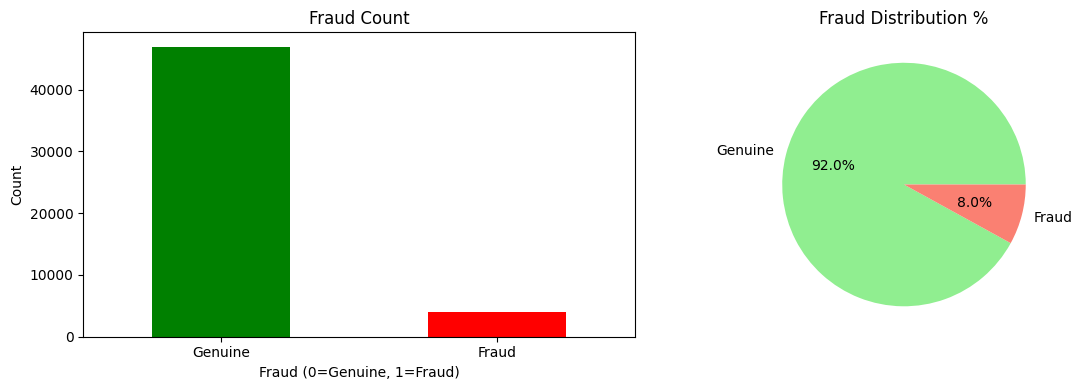

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar plot
df['fraud'].value_counts().plot(kind='bar', ax=axes[0], color=['green', 'red'])
axes[0].set_title('Fraud Count')
axes[0].set_xlabel('Fraud (0=Genuine, 1=Fraud)')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Genuine', 'Fraud'], rotation=0)

# Pie chart
df['fraud'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', 
                                  colors=['lightgreen', 'salmon'],
                                  labels=['Genuine', 'Fraud'])
axes[1].set_title('Fraud Distribution %')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

#### Target Variable (Fraud) Distribution

- The dataset is heavily imbalanced — only **~8% of claims are fraudulent** while the remaining 92% are genuine.
- A model that always predicts 'genuine' would still hit 92% accuracy — so accuracy alone is a completely useless metric here.
- I will prioritize **Recall, F1-score, and AUC-ROC** as evaluation metrics, with Recall being the most critical since missed fraud is the costlier error.
- To handle the imbalance during training, I will evaluate techniques like **SMOTE oversampling, class weighting, and stratified k-fold cross-validation**.
- The ~8% fraud rate mirrors real-world insurance fraud statistics, which adds credibility to the dataset but makes the detection task genuinely hard.

EDA 

\Numeric vs target

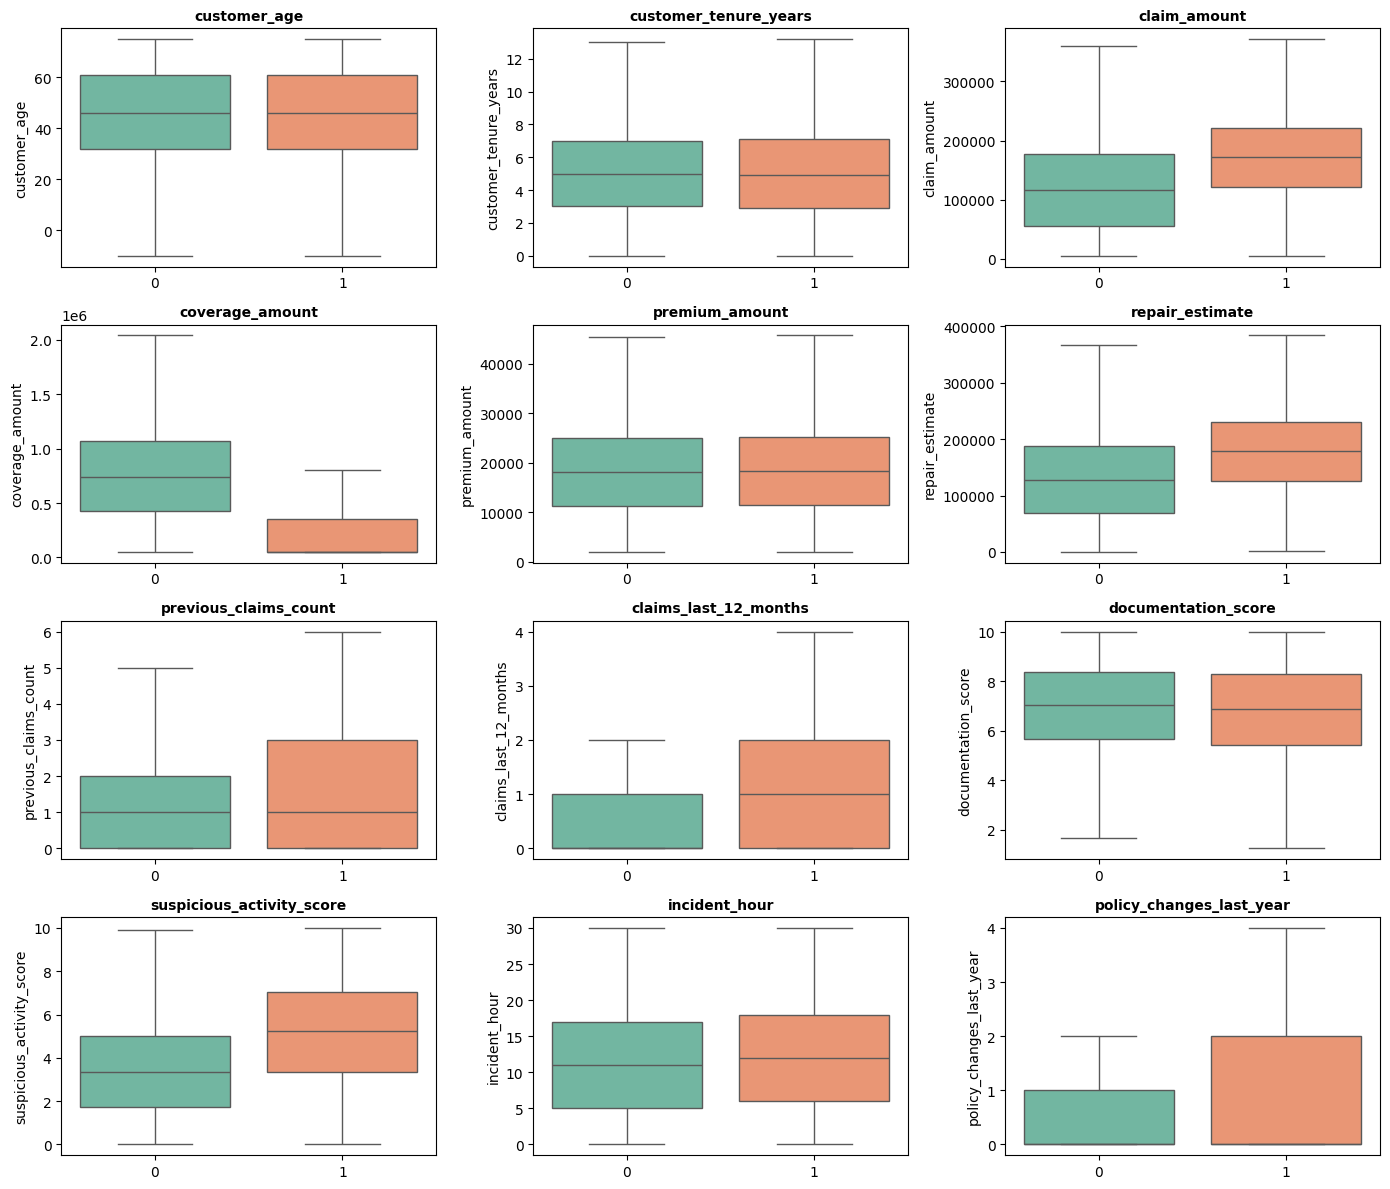

In [46]:
key_numeric = [
    'customer_age', 'customer_tenure_years', 'claim_amount',
    'coverage_amount', 'premium_amount', 'repair_estimate',
    'previous_claims_count', 'claims_last_12_months',
    'documentation_score', 'suspicious_activity_score',
    'incident_hour', 'policy_changes_last_year'
]


df_plot = df.copy()
for col in key_numeric:
    if df_plot[col].dtype == 'object':
        df_plot[col] = pd.to_numeric(
            df_plot[col].astype(str).str.replace(r'[\$,\s"\']', '', regex=True),
            errors='coerce'
        )

fig, axes = plt.subplots(4, 3, figsize=(14, 12))
axes = axes.flatten()

for i, col in enumerate(key_numeric):
    sns.boxplot(data=df_plot, x='fraud', y=col, ax=axes[i],
                palette='Set2', showfliers=False)
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('')

plt.tight_layout()
plt.savefig(r'C:\NG\Insurance_fraud_detection\reports\eda_numeric_vs_fraud.png',
            dpi=80, bbox_inches='tight')
plt.show()


Insights:

Fraudulent claims usually have much higher suspicious activity scores than genuine claims.

Lower documentation scores are commonly linked with fraudulent claims due to weak or incomplete evidence.

Customers with frequent or recent claims are more likely to be involved in fraud.

Fraud cases often show unusually high claim and repair amounts compared to coverage limits.

Policy changes made shortly before a claim can indicate possible fraudulent activity.

\Categorical vs target

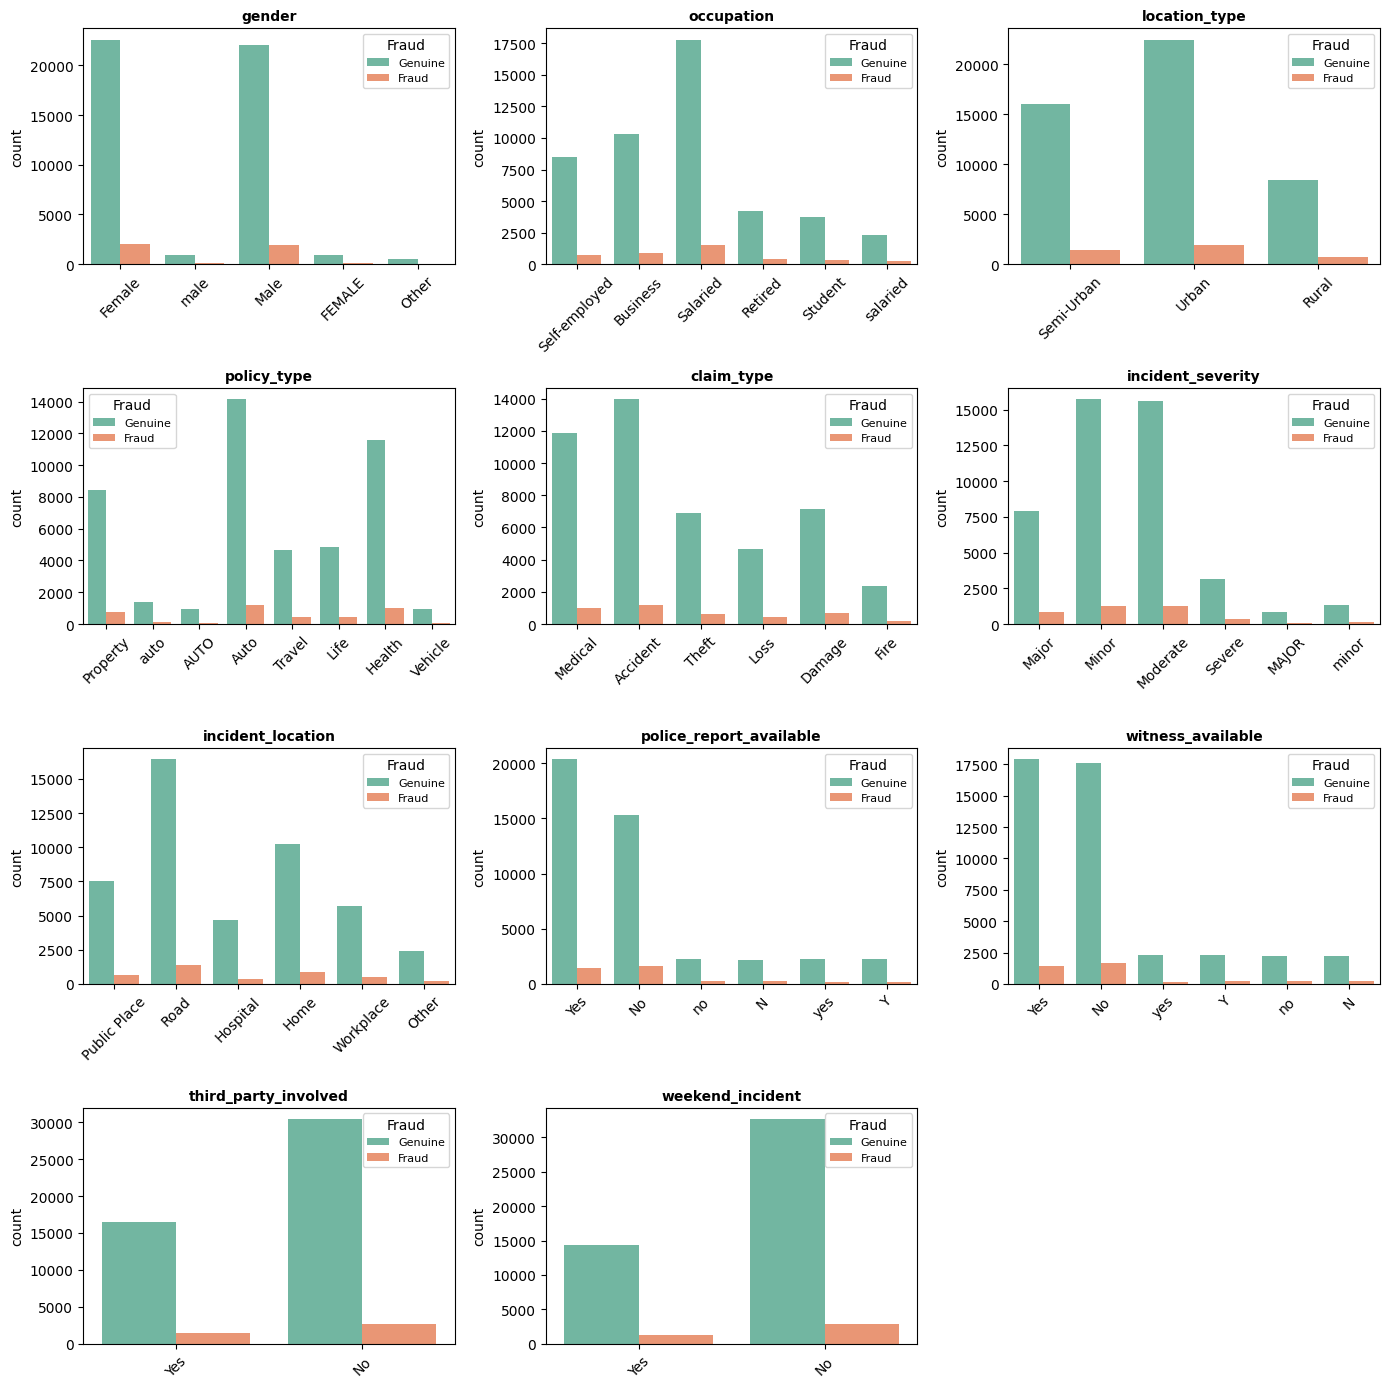

In [47]:
key_categorical = [
    'gender', 'occupation', 'location_type', 'policy_type',
    'claim_type', 'incident_severity', 'incident_location',
    'police_report_available', 'witness_available',
    'third_party_involved', 'weekend_incident'
]

key_categorical = [c for c in key_categorical if c in df.columns]

n = len(key_categorical)
rows = (n + 2) // 3

fig, axes = plt.subplots(rows, 3, figsize=(14, rows*3.5))
axes = axes.flatten()

for i, col in enumerate(key_categorical):
    sns.countplot(data=df_plot, x=col, hue='fraud', ax=axes[i], palette='Set2')
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(title='Fraud', labels=['Genuine', 'Fraud'], fontsize=8)
    axes[i].set_xlabel('')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig(r'C:\NG\Insurance_fraud_detection\reports\eda_categorical_vs_fraud.png',
            dpi=80, bbox_inches='tight')
plt.show()


Insights:

Claims without a police report are much more likely to be fraudulent, especially when no witness is also present.

Fraudulent claims are more common when there are no witnesses to support the incident.

Medical and Theft claims show higher fraud rates compared to Accident and Property claims.

Major severity incidents tend to have a higher chance of fraud because they usually involve larger payouts.

Urban locations show slightly higher fraud activity, but location alone is not a strong fraud indicator.